<a href="https://colab.research.google.com/github/dayquispe/machine-learning-pipeline-clientes/blob/main/Classifica%C3%A7%C3%A3o_Regressao_e_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 - Coleta/seleção do dataset

O dataset utilizado foi o Predict Customer Purchase Behavior Dataset, disponível na plataforma Kaggle.

O objetivo do projeto é prever se um cliente realizará uma compra ou não, caracterizando um problema de classificação binária, utilizando variáveis demográficas e comportamentais

Cada linha do dataset representa um cliente, contendo informações demográficas e comportamentais, como idade, renda anual, número de compras e tempo gasto no site.

As principais variáveis incluem:
- Age `(Idade do cliente)`
- Gender `(Sexo do cliente (0: Masculino, 1: Feminino))`
- Annual Income `(Renda anual do cliente em dólares)`
- Number of Purchases `(Número total de compras realizadas pelo cliente)`
- Product Category `(Categoria do produto comprado (0: Eletrônicos), 1: Vestuário, 2: Artigos para o Lar, 3: Beleza, 4: Esportes)`
- Time Spent on Website `(Tempo gasto pelo cliente no site em minutos)`
- Loyalty Program `(Se o cliente é membro do programa de fidelidade (0: Não, 1: Sim))`
- Discounts Availed `(Número de descontos utilizados pelo cliente (variação: 0-5))`

A variável alvo (**target**) é:

- PurchaseStatus (Status da compra) ==> indica se o cliente realizou uma compra

- 0 = Não comprou

- 1 = Comprou


In [1]:
import pandas as pd
url = 'https://raw.githubusercontent.com/dayquispe/machine-learning-pipeline-clientes/main/customer_purchase_data.csv'
dados = pd.read_csv(url)


In [2]:
dados.head()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,1,66120.267939,8,0,30.568601,0,5,1
1,20,1,23579.773583,4,2,38.240097,0,5,0
2,27,1,127821.306432,11,2,31.633212,1,0,1
3,24,1,137798.623120,19,3,46.167059,0,4,1
4,31,1,99300.964220,19,1,19.823592,0,0,1


# 2 - Preparação dos dados

In [3]:
dados.describe()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000
mean,44.298667,0.504667,84249.164338,10.420000,2.012667,30.469040,0.326667,2.555333,0.43200
std,15.537259,0.500145,37629.493078,5.887391,1.428005,16.984392,0.469151,1.705152,0.49552
min,18.000000,0.000000,20001.512518,0.000000,0.000000,1.037023,0.000000,0.000000,0.00000
25%,31.000000,0.000000,53028.979155,5.000000,1.000000,16.156700,0.000000,1.000000,0.00000
50%,45.000000,1.000000,83699.581476,11.000000,2.000000,30.939516,0.000000,3.000000,0.00000
75%,57.000000,1.000000,117167.772858,15.000000,3.000000,44.369863,1.000000,4.000000,1.00000
max,70.000000,1.000000,149785.176481,20.000000,4.000000,59.991105,1.000000,5.000000,1.00000


In [4]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1500 non-null   int64  
 1   Gender              1500 non-null   int64  
 2   AnnualIncome        1500 non-null   float64
 3   NumberOfPurchases   1500 non-null   int64  
 4   ProductCategory     1500 non-null   int64  
 5   TimeSpentOnWebsite  1500 non-null   float64
 6   LoyaltyProgram      1500 non-null   int64  
 7   DiscountsAvailed    1500 non-null   int64  
 8   PurchaseStatus      1500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 105.6 KB


In [5]:
# Verificando se temos dados nulos
dados.isnull().sum()

,0
Age,0
Gender,0
AnnualIncome,0
NumberOfPurchases,0
ProductCategory,0
TimeSpentOnWebsite,0
LoyaltyProgram,0
DiscountsAvailed,0
PurchaseStatus,0


Não temos dados nulos.

In [6]:
dados.duplicated().sum()

np.int64(112)

In [7]:
dados[dados.duplicated()]

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
243,57,1,79069.053493,8,4,43.221622,0,2,0
271,43,0,101042.774561,14,4,1.596751,0,5,0
299,65,1,55499.205296,20,4,12.778100,0,5,0
304,50,0,41425.926045,6,0,29.865093,1,2,0
306,56,1,48679.553852,17,1,10.110530,0,3,0
...,...,...,...,...,...,...,...,...,...
1461,67,1,110466.885362,17,0,43.108669,0,1,0
1484,68,0,80311.223269,14,2,19.080098,0,3,0
1485,21,1,120794.999552,10,0,7.630770,0,2,0
1492,63,0,71874.591294,10,2,43.546243,0,1,0


Temos 112 duplicadas no dataset, ou seja, registros com valores iguais em todas as variáveis. Essas duplicatas podem influenciar negativamente o desempenho do modelo, por isso vamos remove-las.

In [8]:
dados.drop_duplicates(inplace=True)

In [9]:
dados[dados.duplicated()]

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus


In [10]:
# Temos que verificar se a distribuição das classes, neste caso a coluna PurchaseStatus
round(dados["PurchaseStatus"].value_counts(normalize=True) * 100 , 2)

,proportion
PurchaseStatus,
0,53.31
1,46.69


Estão balanceados, isso é bom

# 3 - Divisão em conjunto de treino e teste

In [11]:
# Vamos separar o conjunto de dados em x e y, variáveis explicativas e a variável target.
X = dados.drop("PurchaseStatus", axis=1)
y = dados["PurchaseStatus"]

## Aqui vamos utilizar o algoritmo de **`Regressão Lógistica`**

In [12]:
# O stratify é para garantir qua a proporção da classe seja mantido tanto em treino
#quanto em teste, vou por mesmo que tenha uma boa distribuição
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.33, random_state=RANDOM_STATE, stratify=y)

print(f"Tamanho do conjunto de treinamento: {len(x_treino)} amostras")
print(f"Tamanho do conjunto de teste: {len(x_teste)} amostras")

Tamanho do conjunto de treinamento: 929 amostras
Tamanho do conjunto de teste: 459 amostras


# 4 - Treinamento do modelo
## 4.1 - Treinamento do modelo LogistcRegression

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler # Usar ele quando temos escalas muito diferente nos dados: Normalização

In [14]:
# Aqui estamos criando o nosso pipeline
logistic_pipeline = make_pipeline(StandardScaler(), # Primeiro com os dados é feita a Normalização
                                  LogisticRegression()) # em seguida o treinamento
logistic_pipeline.fit(x_treino, y_treino)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

In [15]:
# Métricas para avaliação do modelo de classificação
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score, classification_report, confusion_matrix

# Fazendo previsões no conjunto de teste
y_pred = logistic_pipeline.predict(x_teste)

# 5 - Avaliação do modelo
## 5.1 - Avaliação do modelo LogistcRegression

In [16]:
accuracy = accuracy_score(y_teste, y_pred)
precision = precision_score(y_teste, y_pred)
recall = recall_score(y_teste, y_pred)
f1 = f1_score(y_teste, y_pred)

print(f"Accuracy do LR: {accuracy:.3f}")
print(f"Precision do RL: {precision:.3f}")
print(f"Recall do LR: {recall:.3f}")
print(f"F1-score LR: {f1:.3f}")

Accuracy do LR: 0.806
Precision do RL: 0.796
Recall do LR: 0.785
F1-score LR: 0.791


- `Accuracy` mostra que 80,6% das previsões estão corretas.
- `Precision` mostra a porcentagem de quando o modelo diz “vai comprar”, ele acerta ~79,6%
- `Recall` encontra ~78,5% dos clientes que realmente compram
- `F1-score` é quilíbrio entre precision e recall

In [17]:
y_pred_log = logistic_pipeline.predict(x_teste)

print("Matriz de Confusão - Regressão Logística")
print(confusion_matrix(y_teste, y_pred_log))

Matriz de Confusão - Regressão Logística
[[202  43]
 [ 46 168]]


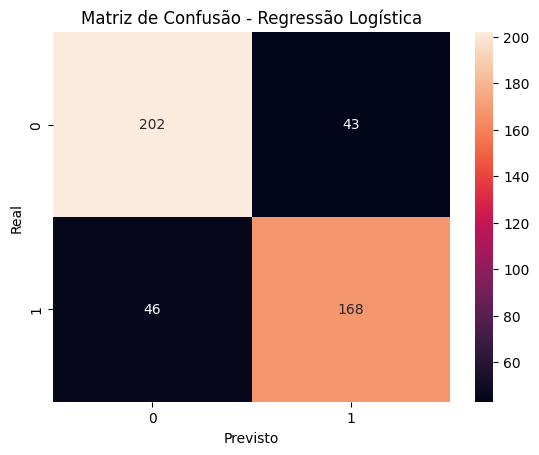

In [18]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt
# gerar matriz
cm = confusion_matrix(y_teste, y_pred_log)
# plotar
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Matriz de Confusão - Regressão Logística")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.show()

- 202: acertou quem NÃO comprou (TN)
- 43: achou que compraria, mas não (FP)
- 46: perdeu clientes que comprariam (FN)
- 168: acertou quem comprou (VP)

## Aqui vamos utilizar o algoritmo **`KNN`**

In [19]:
RANDOM_STATE = 42

x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.33, random_state=RANDOM_STATE, stratify=y)

In [20]:
print(f"Tamanho do conjunto de treinamento: {len(x_treino)} amostras")
print(f"Tamanho do conjunto de teste: {len(x_teste)} amostras")

Tamanho do conjunto de treinamento: 929 amostras
Tamanho do conjunto de teste: 459 amostras


# 4 - Treinamento do modelo
## 4.2 - Treinamento do modelo KNN

In [21]:
from sklearn.neighbors import KNeighborsClassifier

Aqui o KNN usa 5 vizinhos mais próximos e parecidos para tomar a decisão.
Ou seja, ele olha 5 clientes parecidos e vê se eles compraram ou não.
A decisão final é feita pela maioria.

In [22]:
# Aqui estamos criando o nosso pipeline
knn_pipeline = make_pipeline(
    StandardScaler(), #Primeiro com os dados é feita a Normalização
    KNeighborsClassifier(n_neighbors=7) #  e em seguida o treinamento
)
knn_pipeline.fit(x_treino, y_treino)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kneighborsclassifier', KNeighborsClassifier(n_neighbors=7))])

In [23]:
# Fazendo previsões no conjunto de teste
y_pred = knn_pipeline.predict(x_teste)

# 5 - Avaliação do modelo
## 5.1 - Avaliação do modelo KNN

In [24]:
accuracy = accuracy_score(y_teste, y_pred)
precision = precision_score(y_teste, y_pred)
recall = recall_score(y_teste, y_pred)
f1 = f1_score(y_teste, y_pred)

print(f"Accuracy do KNN: {accuracy:.3f}")
print(f"Precision do KNN: {precision:.3f}")
print(f"Recall do KNN: {recall:.3f}")
print(f"F1-score KNN: {f1:.3f}")

Accuracy do KNN: 0.834
Precision do KNN: 0.797
Recall do KNN: 0.864
F1-score KNN: 0.830


- `Accuracy` mostra que 83,4% das previsões estão corretas, melhor que o da logística.
- `Precision` mostra a porcentagem de quando o modelo diz “vai comprar”, ele acerta ~79,7%.
- `Recall` encontra ~86,4% dos clientes que realmente compram, muito melhor que o da regressão logística.
- `F1-score` é quilíbrio entre precision e recall, que por sinal esta maior.

In [25]:
y_pred_knn = knn_pipeline.predict(x_teste)

print("Matriz de Confusão - KNN")
print(confusion_matrix(y_teste, y_pred_knn))

Matriz de Confusão - KNN
[[198  47]
 [ 29 185]]


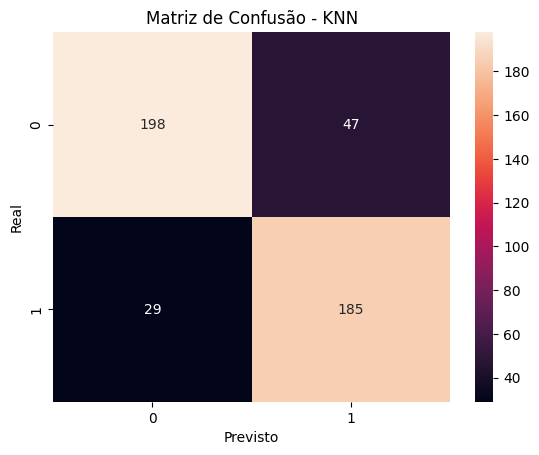

In [26]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt
# gerar matriz
cm = confusion_matrix(y_teste, y_pred_knn)
# plotar
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Matriz de Confusão - KNN")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.show()

- 198: acertou quem não comprou
- 47: errou (falso positivo)
- 29: perdeu menos clientes
- 185: acertou mais clientes

No projeto, foram desenvolvidos modelos de classificação com o objetivo de prever se um cliente vai realizar uma compra ou não.

Foram utilizados os algoritmos de Regressão Logística e KNN, e a avaliação foi feita usando métricas como acurácia, precisão, recall e F1-score, além da matriz de confusão.

Analisando os resultados, foi possível perceber que o modelo KNN apresentou um desempenho melhor, com acurácia de 83,4%, recall de 86,4% e F1-score de 83%, superando a Regressão Logística.

O recall foi considerado uma métrica importante nesse problema, pois ajuda a identificar corretamente os clientes que realmente compram, evitando perder possíveis clientes. Nesse ponto, o KNN se destacou, já que teve menos falsos negativos.

Portanto, pode-se concluir que o modelo KNN é o mais adequado para este caso, pois apresentou melhores resultados e conseguiu identificar melhor os clientes com maior chance de compra.”

Mas o modelo pode ser melhor:
- Ajustando o algoritmo (hiperparâmetros)
- Melhorar os dados
- Escolher melhores variáveis
- Trocando o valor de n_neighbors (valor de K) para o de KNN, por que o 5 pode não ser o melhor
- Ter feito uma Feature Selection

In [27]:
# Mostra qual valor de K é melhor

from sklearn.model_selection import GridSearchCV

param_grid = {
    'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11]
}

grid = GridSearchCV(knn_pipeline, param_grid, cv=5, scoring='f1')

grid.fit(x_treino, y_treino)

print("Melhor K:", grid.best_params_)
print("Melhor score:", grid.best_score_)

Melhor K: {'kneighborsclassifier__n_neighbors': 7}
Melhor score: 0.8134861048664843


O melhor K é 7

In [28]:
coeficientes = pd.DataFrame({
    "Variavel": X.columns,
    "Peso": logistic_pipeline.named_steps['logisticregression'].coef_[0]
})

print(coeficientes.sort_values(by="Peso", ascending=False))

             Variavel      Peso
6      LoyaltyProgram  1.235842
7    DiscountsAvailed  1.072194
5  TimeSpentOnWebsite  1.051927
2        AnnualIncome  0.791355
3   NumberOfPurchases  0.595841
1              Gender  0.052886
4     ProductCategory  0.050061
0                 Age -0.938570


O resultado acima mostra o quanto cada variável influencia na decisão do modelo, onde:
- valor positivo (+) ->  aumenta chance de compra
- valor negativo (-) -> diminui chance
- valor próximo de 0 ->  pouca influência

Variáveis como Gender e ProductCategory apresentaram pouca influência no modelo, indicando que não são tão relevantes para a predição, mas isso não quer dizer que temos que excluir esses dados, mas sim testar seu impacto no modelo.
